# B25 - Evaluation metrics Notebook

This notebook explores the demographics, dwell, footfall and sales data provided.
NOTE: Analysis has not been finished.

In [282]:
pip install matplotlib geopandas numpy scipy folium plotly

Note: you may need to restart the kernel to use updated packages.


In [283]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

In [284]:
non_ticketed_events = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\DATA\Non ticketed Events Venues (Non-Ticketed Events).csv", encoding='latin1')
non_ticketed_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   start_date             3332 non-null   object
 1   end_date               3332 non-null   object
 2   item_type              3333 non-null   object
 3   project_name_internal  234 non-null    object
 4   evaluation_category    3333 non-null   object
 5   Event (activity)       3333 non-null   object
 6   venue                  3266 non-null   object
 7   Venues                 3333 non-null   object
 8   Postcode               3331 non-null   object
 9   ticketed               3333 non-null   object
dtypes: object(10)
memory usage: 260.5+ KB


In [285]:
non_ticketed_events['Venues'].unique()

array(['Marie Curie Centre', 'Foundation for Contemporary Art',
       'Bingley Arts Centre', 'Bingley Skate Park', 'Myrtle Park',
       'Kirkgate Community Centre', 'Beacon - Cliffe Castle',
       'Cliffe Castle Museum', 'Cardigan house  ', 'Stage 84',
       'Scholemoor Beacon', 'TFD Youth Centre', 'Summat Creative CIC',
       'All Star Entertainment', 'Laisterdyke Community Centre',
       'Loading Bay', 'Kala Sangam (Temporary Address)',
       'Skylight lounge  ', 'Bolton Woods Centre', 'Beacon - Lister Park',
       'Lady Royd Primary School', 'Bradford Academy - Secondary',
       'Beacon - Wibsey Park', 'Mustafa Centre',
       "St Mary Magdalene's Church", 'Beacon - Bowling Park',
       'The Valley Project', 'Bradford New Church',
       'Lower Grange Community Centre', 'Hall Ings', 'Bradford 2025',
       'City Centre', '0', 'Ladyhill Park', 'Play Bradford',
       'Keighley Library', 'Hainworth Wood Community Centre',
       'Sandale Trust Centre (Reevy Road) ', 'Centena

## Combining the demographics, dwell, footfall and sales data of the 13 areas provided

In [286]:
import glob
import os

#Folder with containing all areas
folder_path = r"C:\Users\qxnq723\Desktop\Project 1\DATA\Footfall data"

#Find all CSVs in all subfolders
area_folders = glob.glob(os.path.join(folder_path, '*'))

#Define file names
custom_names = ['demographics', 'dwell', 'footfall', 'sales']

#Dict to store combined dataframes by file type
combined = {name: pd.DataFrame() for name in custom_names}

for area_path in area_folders:
    #Get area name
    area_name = os.path.basename(area_path)
    
    csv_files = sorted(glob.glob(os.path.join(area_path, '*.csv')))
    
    #Loop over CSVs and assign new name
    for i, file in enumerate (csv_files):
        df = pd.read_csv(file, encoding='cp1252')
        
        #Add area column
        df['region'] = area_name
        
        #Get the new names
        new_name = custom_names[i]
        
        #Concatenate into 
        combined[new_name] = pd.concat([combined[new_name], df], ignore_index=True)

#Check
print(combined['demographics'].head())

                                                area         Category  Group  \
0  Coates Street, Bradford Foyer, Coates TER, Woo...  Age (Residents)   0-14   
1  Coates Street, Bradford Foyer, Coates TER, Woo...  Age (Residents)  15-29   
2  Coates Street, Bradford Foyer, Coates TER, Woo...  Age (Residents)  30-44   
3  Coates Street, Bradford Foyer, Coates TER, Woo...  Age (Residents)  45-59   
4  Coates Street, Bradford Foyer, Coates TER, Woo...  Age (Residents)    60+   

   Value                                             region  
0  29.0%  Balancing Acts - 1 Coates Street, Bradford, BD...  
1  23.3%  Balancing Acts - 1 Coates Street, Bradford, BD...  
2  23.2%  Balancing Acts - 1 Coates Street, Bradford, BD...  
3  13.3%  Balancing Acts - 1 Coates Street, Bradford, BD...  
4  11.2%  Balancing Acts - 1 Coates Street, Bradford, BD...  


In [287]:
print(combined['demographics']['region'].unique())

['Balancing Acts - 1 Coates Street, Bradford, BD5 7DL'
 'BD Walls Come on in my friend - BD6 3PU'
 'BD WALLS RAVO- Roundwood Ave, Bradford BD10 0LL'
 'BD WALLS Root - 1 Coates St, Bradford BD5 7DL'
 'BD WALLS Serving the district - Morrisons, Bradford Road, Idle BD10'
 'BD WALLS The Portal - Church Bank House BD1'
 'BD WALLS Wayfinders - 15 Park Road, Bingley' 'Bradford BID'
 'Bradford city centre' 'Darley Street Market' 'Lister park'
 'Painting the Sky - Roberts Park BD17 7LU' 'WILD UPLANDS']


In [288]:
combined.keys()

dict_keys(['demographics', 'dwell', 'footfall', 'sales'])

In [289]:
#Extract into separate dataframes
df_demo = combined['demographics']
df_dwell = combined['dwell']
df_footfall = combined['footfall']
df_sales = combined['sales']

## 1 - Exploratory Data Analysis: Demographics

In [327]:
df_demo.head()

,area,Category,Group,Value,region
0,"Coates Street, Bradford Foyer, Coates TER, Woo...",Age (Residents),0-14,29.0,"Balancing Acts - 1 Coates Street, Bradford, BD..."
1,"Coates Street, Bradford Foyer, Coates TER, Woo...",Age (Residents),15-29,23.3,"Balancing Acts - 1 Coates Street, Bradford, BD..."
2,"Coates Street, Bradford Foyer, Coates TER, Woo...",Age (Residents),30-44,23.2,"Balancing Acts - 1 Coates Street, Bradford, BD..."
3,"Coates Street, Bradford Foyer, Coates TER, Woo...",Age (Residents),45-59,13.3,"Balancing Acts - 1 Coates Street, Bradford, BD..."
4,"Coates Street, Bradford Foyer, Coates TER, Woo...",Age (Residents),60+,11.2,"Balancing Acts - 1 Coates Street, Bradford, BD..."


In [291]:
#Take out the % for calculations
df_demo['Value'] = df_demo['Value'].str.replace('%', '', regex=True)
#Convert Value column to numerical instead of object
df_demo['Value'] = pd.to_numeric(df_demo['Value'], errors='coerce')
df_demo.head()

,area,Category,Group,Value,region
0,"Coates Street, Bradford Foyer, Coates TER, Woo...",Age (Residents),0-14,29.0,"Balancing Acts - 1 Coates Street, Bradford, BD..."
1,"Coates Street, Bradford Foyer, Coates TER, Woo...",Age (Residents),15-29,23.3,"Balancing Acts - 1 Coates Street, Bradford, BD..."
2,"Coates Street, Bradford Foyer, Coates TER, Woo...",Age (Residents),30-44,23.2,"Balancing Acts - 1 Coates Street, Bradford, BD..."
3,"Coates Street, Bradford Foyer, Coates TER, Woo...",Age (Residents),45-59,13.3,"Balancing Acts - 1 Coates Street, Bradford, BD..."
4,"Coates Street, Bradford Foyer, Coates TER, Woo...",Age (Residents),60+,11.2,"Balancing Acts - 1 Coates Street, Bradford, BD..."


In [292]:
#Create pivot table for better readability
pivot = df_demo.pivot_table(index= 'area', 
                            columns= ['Category', 'Group'], 
                            values='Value',
                            aggfunc= 'mean')

pivot

Category                                           Age (Residents)        \
Group                                                         0-14 15-29   
area                                                                       
BD WALL - Wayfinders                                          16.5  15.2   
BD Walls - The Portal                                         19.3  37.0   
BD Walls : Serving the district                               19.0  16.6   
BD Walls Roots                                                29.0  23.3   
Baildon                                                       17.2  15.3   
Bradford                                                      25.2  23.8   
Bradford - City Centre                                        18.7  40.3   
Bradford - Penistone Hill                                     15.7  13.5   
Bradford BID                                                  24.2  31.1   
Coates Street, Bradford Foyer, Coates TER, Woot...            29.0  23.3   
Draley Street Market                                          19.3  37.0   
Reevy Road                                                    22.1  17.0   
Roundwood Avenue                                              21.0  17.0   

Category                                                              \
Group                                              30-44 45-59   60+   
area                                                                   
BD WALL - Wayfinders                                18.6  22.2  27.4   
BD Walls - The Portal                               29.8   8.8   5.1   
BD Walls : Serving the district                     17.9  21.3  25.1   
BD Walls Roots                                      23.2  13.3  11.2   
Baildon                                             21.4  21.0  25.0   
Bradford                                            23.3  14.5  13.1   
Bradford - City Centre                              24.3   9.8   6.9   
Bradford - Penistone Hill                           16.8  25.8  27.6   
Bradford BID                                        24.2  11.5   8.9   
Coates Street, Bradford Foyer, Coates TER, Woot...  23.2  13.3  11.2   
Draley Street Market                                29.8   8.8   5.1   
Reevy Road                                          19.3  20.2  21.4   
Roundwood Avenue                                    20.3  20.0  21.5   

Category                                           Age (Visitors)              \
Group                                                       15-29 30-44 45-59   
area                                                                            
BD WALL - Wayfinders                                         20.5  22.8  25.8   
BD Walls - The Portal                                        28.3  29.5  21.1   
BD Walls : Serving the district                              22.6  24.9  25.3   
BD Walls Roots                                               28.7  29.6  21.1   
Baildon                                                      20.5  23.0  25.8   
Bradford                                                     26.9  27.5  22.3   
Bradford - City Centre                                       28.2  27.4  21.9   
Bradford - Penistone Hill                                    19.8  22.7  26.6   
Bradford BID                                                 28.0  27.6  21.8   
Coates Street, Bradford Foyer, Coates TER, Woot...           26.5  28.7  22.4   
Draley Street Market                                         30.0  27.5  21.2   
Reevy Road                                                   23.4  25.4  24.9   
Roundwood Avenue                                             23.0  25.9  25.2   

Category                                                 Gender (Residents)  \
Group                                                60+                  F   
area                                                                          
BD WALL - Wayfinders                                30.9               49.9   
BD Walls - The Po

In [293]:
pivot.describe()

Category Age (Residents)                                              \
Group               0-14      15-29      30-44      45-59        60+   
count          13.000000  13.000000  13.000000  13.000000  13.000000   
mean           21.246154  23.876923  22.469231  16.192308  16.115385   
std             4.417317   9.447500   4.077046   5.772992   8.722084   
min            15.700000  13.500000  16.800000   8.800000   5.100000   
25%            18.700000  16.600000  19.300000  11.500000   8.900000   
50%            19.300000  23.300000  23.200000  14.500000  13.100000   
75%            24.200000  31.100000  24.200000  21.000000  25.000000   
max            29.000000  40.300000  29.800000  25.800000  27.600000   

Category Age (Visitors)                                  Gender (Residents)  \
Group             15-29      30-44      45-59        60+                  F   
count         13.000000  13.000000  13.000000  13.000000          13.000000   
mean          25.107692  26.346154  23.492308  25.069231          48.915385   
std            3.586889   2.443909   2.105335   3.860782           2.516561   
min           19.800000  22.700000  21.100000  20.500000          44.800000   
25%           22.600000  24.900000  21.800000  22.500000          47.300000   
50%           26.500000  27.400000  22.400000  23.300000          49.000000   
75%           28.200000  27.600000  25.300000  27.200000          50.600000   
max           30.000000  29.600000  26.600000  30.900000          52.300000   

Category  ... Purchasing Power Buckets (Visitors)                            \
Group     ...                        Bucket 49000 Bucket 52500 Bucket 56000   
count     ...                                 2.0          2.0          3.0   
mean      ...                                 0.0          0.0          0.0   
std       ...                                 0.0          0.0          0.0   
min       ...                                 0.0          0.0          0.0   
25%       ...                                 0.0          0.0          0.0   
50%       ...                                 0.0          0.0          0.0   
75%       ...                                 0.0          0.0          0.0   
max       ...                                 0.0          0.0          0.0   

Category                                                                  \
Group    Bucket 63000 Bucket 66500 Bucket 7000 Bucket 70000 Bucket 80500   
count             4.0          2.0   13.000000          2.0          1.0   
mean              0.0          0.0    2.846154          0.0          0.0   
std               0.0          0.0    1.625123          0.0          NaN   
min               0.0          0.0    1.000000          0.0          0.0   
25%               0.0          0.0    2.000000          0.0          0.0   
50%               0.0          0.0    2.000000          0.0          0.0   
75%               0.0          0.0    4.000000          0.0          0.0   
max               0.0          0.0    6.000000          0.0          0.0   

Category                            
Group    Bucket 91000 Bucket 94500  
count             2.0          3.0  
mean              0.0          0.0  
std               0.0          0.0  
min               0.0          0.0  
25%               0.0          0.0  
50%               0.0          0.0  
75%               0.0          0.0  
max               0.0          0.0  

[8 rows x 41 columns]

In [294]:
pivot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, BD WALL - Wayfinders to Roundwood Avenue
Data columns (total 41 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   (Age (Residents), 0-14)                               13 non-null     float64
 1   (Age (Residents), 15-29)                              13 non-null     float64
 2   (Age (Residents), 30-44)                              13 non-null     float64
 3   (Age (Residents), 45-59)                              13 non-null     float64
 4   (Age (Residents), 60+)                                13 non-null     float64
 5   (Age (Visitors), 15-29)                               13 non-null     float64
 6   (Age (Visitors), 30-44)                               13 non-null     float64
 7   (Age (Visitors), 45-59)                               13 non-null     float64
 8   (Age (Visitors), 60+)             

### A) Investigate Age

In [295]:
age_res = pivot['Age (Residents)']
age_vis = pivot['Age (Visitors)']

In [296]:
#Find dominant resident age group of each area
age_res.idxmax(axis=1)

area
BD WALL - Wayfinders                                           60+
BD Walls - The Portal                                        15-29
BD Walls : Serving the district                                60+
BD Walls Roots                                                0-14
Baildon                                                        60+
Bradford                                                      0-14
Bradford - City Centre                                       15-29
Bradford - Penistone Hill                                      60+
Bradford BID                                                 15-29
Coates Street, Bradford Foyer, Coates TER, Wootton Street     0-14
Draley Street Market                                         15-29
Reevy Road                                                    0-14
Roundwood Avenue                                               60+
dtype: object

In [297]:
#Find dominant visitor age group of each area
age_vis.idxmax(axis=1)

area
BD WALL - Wayfinders                                           60+
BD Walls - The Portal                                        30-44
BD Walls : Serving the district                                60+
BD Walls Roots                                               30-44
Baildon                                                        60+
Bradford                                                     30-44
Bradford - City Centre                                       15-29
Bradford - Penistone Hill                                      60+
Bradford BID                                                 15-29
Coates Street, Bradford Foyer, Coates TER, Wootton Street    30-44
Draley Street Market                                         15-29
Reevy Road                                                     60+
Roundwood Avenue                                               60+
dtype: object

In [298]:
#Difference in age
age_diff = pivot['Age (Visitors)'] - pivot['Age (Residents)']
age_diff

Group,0-14,15-29,30-44,45-59,60+
area,,,,,
BD WALL - Wayfinders,NaN,5.3,4.2,3.6,3.5
BD Walls - The Portal,NaN,-8.7,-0.3,12.3,16.1
BD Walls : Serving the district,NaN,6.0,7.0,4.0,2.1
BD Walls Roots,NaN,5.4,6.4,7.8,9.3
Baildon,NaN,5.2,1.6,4.8,5.7
Bradford,NaN,3.1,4.2,7.8,10.2
Bradford - City Centre,NaN,-12.1,3.1,12.1,15.6
Bradford - Penistone Hill,NaN,6.3,5.9,0.8,3.3
Bradford BID,NaN,-3.1,3.4,10.3,13.6


In [299]:
#Biggest visitor vs resident gaps
age_diff.abs().max(axis=1).sort_values(ascending=False)

area
Draley Street Market                                         16.3
BD Walls - The Portal                                        16.1
Bradford - City Centre                                       15.6
Bradford BID                                                 13.6
Coates Street, Bradford Foyer, Coates TER, Wootton Street    11.3
Bradford                                                     10.2
BD Walls Roots                                                9.3
BD Walls : Serving the district                               7.0
Reevy Road                                                    6.4
Bradford - Penistone Hill                                     6.3
Roundwood Avenue                                              6.0
Baildon                                                       5.7
BD WALL - Wayfinders                                          5.3
dtype: float64

In [300]:
#Create a 0-14 age group for visitors and fill with 0s (allows easier comparison)
pivot.loc[:, ('Age (Visitors)', '0-14')] = 0

#Re-order the columns
visitor_age_order = ['0-14', '15-29', '30-44', '45-59', '60+']
pivot['Age (Visitors)'] = pivot['Age (Visitors)'].reindex(columns = visitor_age_order)

#Reindex pivot table to include the new column
pivot = pivot.reindex(
    columns=sorted(
        pivot.columns,
        key= lambda x: (
            x[0] != 'Age (Visitors)',
            ['0-14', '15-29', '30-44', '45-59', '60+'].index(x[1]) if x[0]=='Age (Visitors)' else 0
        )
    )
)

#Check
pivot

Category                                           Age (Visitors)              \
Group                                                        0-14 15-29 30-44   
area                                                                            
BD WALL - Wayfinders                                            0  20.5  22.8   
BD Walls - The Portal                                           0  28.3  29.5   
BD Walls : Serving the district                                 0  22.6  24.9   
BD Walls Roots                                                  0  28.7  29.6   
Baildon                                                         0  20.5  23.0   
Bradford                                                        0  26.9  27.5   
Bradford - City Centre                                          0  28.2  27.4   
Bradford - Penistone Hill                                       0  19.8  22.7   
Bradford BID                                                    0  28.0  27.6   
Coates Street, Bradford Foyer, Coates TER, Woot...              0  26.5  28.7   
Draley Street Market                                            0  30.0  27.5   
Reevy Road                                                      0  23.4  25.4   
Roundwood Avenue                                                0  23.0  25.9   

Category                                                        \
Group                                              45-59   60+   
area                                                             
BD WALL - Wayfinders                                25.8  30.9   
BD Walls - The Portal                               21.1  21.2   
BD Walls : Serving the district                     25.3  27.2   
BD Walls Roots                                      21.1  20.5   
Baildon                                             25.8  30.7   
Bradford                                            22.3  23.3   
Bradford - City Centre                              21.9  22.5   
Bradford - Penistone Hill                           26.6  30.9   
Bradford BID                                        21.8  22.5   
Coates Street, Bradford Foyer, Coates TER, Woot...  22.4  22.5   
Draley Street Market                                21.2  21.4   
Reevy Road                                          24.9  26.3   
Roundwood Avenue                                    25.2  26.0   

Category                                           Age (Residents)        \
Group                                                         0-14 15-29   
area                                                                       
BD WALL - Wayfinders                                          16.5  15.2   
BD Walls - The Portal                                         19.3  37.0   
BD Walls : Serving the district                               19.0  16.6   
BD Walls Roots                                                29.0  23.3   
Baildon                                                       17.2  15.3   
Bradford                                                      25.2  23.8   
Bradford - City Centre                                        18.7  40.3   
Bradford - Penistone Hill                                     15.7  13.5   
Bradford BID                                                  24.2  31.1   
Coates Street, Bradford Foyer, Coates TER, Woot...            29.0  23.3   
Draley Street Market                                          19.3  37.0   
Reevy Road                                                    22.1  17.0   
Roundwood Avenue                                              21.0  17.0   

Category                                                              ...  \
Group                                              30-44 45-59   60+  ...   
area                                                                  ...   
BD WALL - Wayfinders                                18.6  22.2  27.4  ...   
BD Walls - The Portal                               29.8   8.8   5.1  ...   
BD Walls : Serving the district             

In [301]:
#Isolate the residents vs visitors
age_res = pivot['Age (Residents)']
age_vis = pivot['Age (Visitors)']

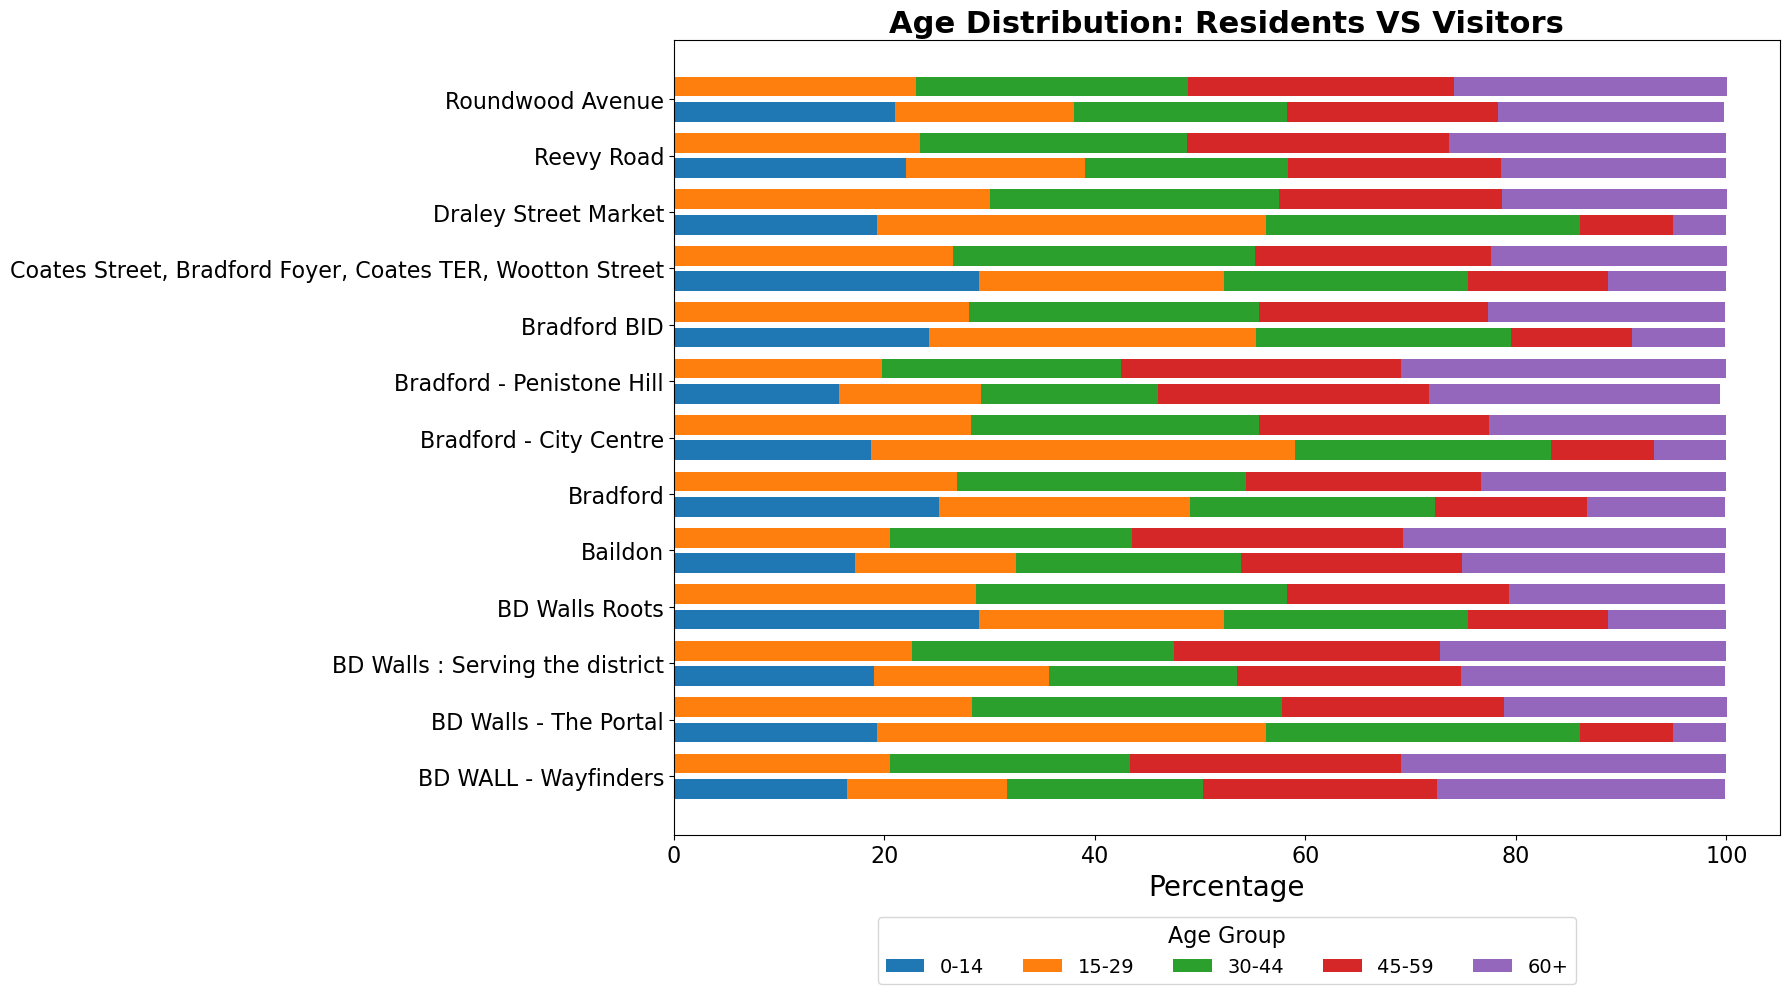

In [302]:
#Plot a Stacked Bar Chart

n_areas = len(pivot)
y = np.arange(n_areas)

fig, ax = plt.subplots(figsize=(18, 10))

#Use same color palette for both
colors = plt.cm.tab10.colors
age_cols_res = age_res.columns
age_cols_vis = age_vis.columns

offset = ( 0.35 + 0.1) /2

#Plot Residents (with labels)
left = np.zeros(n_areas)
for i, col in enumerate(age_cols_res):
    ax.barh(y - offset, age_res[col], left=left, height= 0.35, label=col, color=colors[i])
    left += age_res[col].values

#Plot Visitors (no labels)
left = np.zeros(n_areas)
for i, col in enumerate(age_cols_vis):
    ax.barh(y + offset, age_vis[col], left=left, height= 0.35, label= '_nolegned_', color=colors[i])
    left += age_vis[col].values

ax.set_yticks(y)
ax.set_yticklabels(pivot.index, fontsize= 16)
ax.tick_params(axis='x', labelsize= 16)
ax.set_xlabel('Percentage', fontsize= 20)
ax.set_title('Age Distribution: Residents VS Visitors', fontsize= 22, weight= 'bold')
ax.legend(title='Age Group', title_fontsize= 16, bbox_to_anchor=(0.5, -0.2), loc='lower center', fontsize=14, ncol=len(age_cols_res))
plt.tight_layout()
plt.show()

### B) Investigate Gender

In [ ]:
#Look into gender differences:
gender_res = pivot['Gender (Residents)']
gender_vis = pivot['Gender (Visitors)']

gender_vis

Group,Female,Male
area,,
BD WALL - Wayfinders,50.4,49.6
BD Walls - The Portal,50.0,50.0
BD Walls : Serving the district,50.9,49.1
BD Walls Roots,50.1,49.9
Baildon,50.6,49.4
Bradford,50.3,49.7
Bradford - City Centre,50.2,49.8
Bradford - Penistone Hill,50.9,49.1
Bradford BID,50.0,50.0


In [304]:
gender_res

Group,F,M
area,,
BD WALL - Wayfinders,49.9,50.1
BD Walls - The Portal,44.8,55.2
BD Walls : Serving the district,51.3,48.7
BD Walls Roots,49.0,51.0
Baildon,50.4,49.6
Bradford,48.6,51.4
Bradford - City Centre,46.1,53.9
Bradford - Penistone Hill,50.6,49.4
Bradford BID,47.3,52.7


In [305]:
#Gender Difference
gender_diff_res = abs(pivot['Gender (Residents)']['F'] - pivot['Gender (Residents)']['M'])
gender_diff_vis = abs(pivot['Gender (Visitors)']['Female'] - pivot['Gender (Visitors)']['Male'])

In [306]:
gender_diff_res

area
BD WALL - Wayfinders                                          0.2
BD Walls - The Portal                                        10.4
BD Walls : Serving the district                               2.6
BD Walls Roots                                                2.0
Baildon                                                       0.8
Bradford                                                      2.8
Bradford - City Centre                                        7.8
Bradford - Penistone Hill                                     1.2
Bradford BID                                                  5.4
Coates Street, Bradford Foyer, Coates TER, Wootton Street     2.0
Draley Street Market                                         10.4
Reevy Road                                                    4.6
Roundwood Avenue                                              3.6
dtype: float64

In [307]:
gender_diff_vis

area
BD WALL - Wayfinders                                         0.8
BD Walls - The Portal                                        0.0
BD Walls : Serving the district                              1.8
BD Walls Roots                                               0.2
Baildon                                                      1.2
Bradford                                                     0.6
Bradford - City Centre                                       0.4
Bradford - Penistone Hill                                    1.8
Bradford BID                                                 0.0
Coates Street, Bradford Foyer, Coates TER, Wootton Street    0.6
Draley Street Market                                         0.2
Reevy Road                                                   3.2
Roundwood Avenue                                             2.8
dtype: float64

### C) Investigate Residents Household and Population

In [311]:
print(pivot['Population (Residents)']['Average Household Size'])
print((pivot['Population (Residents)']['Average Household Size']).mean())

area
BD WALL - Wayfinders                                         2.21
BD Walls - The Portal                                        2.01
BD Walls : Serving the district                              2.36
BD Walls Roots                                               2.93
Baildon                                                      2.27
Bradford                                                     3.35
Bradford - City Centre                                       2.52
Bradford - Penistone Hill                                    2.18
Bradford BID                                                 2.77
Coates Street, Bradford Foyer, Coates TER, Wootton Street    2.93
Draley Street Market                                         2.01
Reevy Road                                                   2.40
Roundwood Avenue                                             2.33
Name: Average Household Size, dtype: float64
2.482307692307692


In [313]:
print(pivot['Population (Residents)']['Households'])
print((pivot['Population (Residents)']['Households']).mean())
print((pivot['Population (Residents)']['Households']).max())

area
BD WALL - Wayfinders                                         3800.0
BD Walls - The Portal                                        1052.0
BD Walls : Serving the district                              3099.0
BD Walls Roots                                               4343.0
Baildon                                                      2886.0
Bradford                                                     3583.0
Bradford - City Centre                                       2309.0
Bradford - Penistone Hill                                     491.0
Bradford BID                                                 6369.0
Coates Street, Bradford Foyer, Coates TER, Wootton Street    4343.0
Draley Street Market                                         1052.0
Reevy Road                                                   2905.0
Roundwood Avenue                                             1242.0
Name: Households, dtype: float64
2882.6153846153848
6369.0


In [314]:
print(pivot['Population (Residents)']['Total Population'])
print((pivot['Population (Residents)']['Total Population']).mean())
print((pivot['Population (Residents)']['Total Population']).max())

area
BD WALL - Wayfinders                                          8401.0
BD Walls - The Portal                                         2119.0
BD Walls : Serving the district                               7310.0
BD Walls Roots                                               12720.0
Baildon                                                       6555.0
Bradford                                                     12001.0
Bradford - City Centre                                        5817.0
Bradford - Penistone Hill                                     1073.0
Bradford BID                                                 17666.0
Coates Street, Bradford Foyer, Coates TER, Wootton Street    12720.0
Draley Street Market                                          2119.0
Reevy Road                                                    6969.0
Roundwood Avenue                                              2890.0
Name: Total Population, dtype: float64
7566.153846153846
17666.0


### D) Investigate Purchasing Power

In [320]:
print(pivot['Purchasing Power (Residents)']['EUR per capita'])
print((pivot['Purchasing Power (Residents)']['EUR per capita']).mean())
print((pivot['Purchasing Power (Residents)']['EUR per capita']).max())
print((pivot['Purchasing Power (Residents)']['EUR per capita']).min())

area
BD WALL - Wayfinders                                         27877.53
BD Walls - The Portal                                        21323.23
BD Walls : Serving the district                              20253.47
BD Walls Roots                                               11998.92
Baildon                                                      28024.93
Bradford                                                     14075.33
Bradford - City Centre                                       17158.52
Bradford - Penistone Hill                                    26529.70
Bradford BID                                                 13972.29
Coates Street, Bradford Foyer, Coates TER, Wootton Street    11998.92
Draley Street Market                                         21323.23
Reevy Road                                                   18358.11
Roundwood Avenue                                             21793.36
Name: EUR per capita, dtype: float64
19591.349230769232
28024.93
11998.92


In [317]:
print(pivot['Purchasing Power (Visitors)']['EUR per capita'])
print((pivot['Purchasing Power (Visitors)']['EUR per capita']).mean())
print((pivot['Purchasing Power (Visitors)']['EUR per capita']).max())
print((pivot['Purchasing Power (Visitors)']['EUR per capita']).min())

area
BD WALL - Wayfinders                                         25135.73
BD Walls - The Portal                                        17787.54
BD Walls : Serving the district                              19647.13
BD Walls Roots                                               15047.41
Baildon                                                      23756.10
Bradford                                                     18111.83
Bradford - City Centre                                       17640.06
Bradford - Penistone Hill                                    23017.82
Bradford BID                                                 18097.79
Coates Street, Bradford Foyer, Coates TER, Wootton Street    15948.99
Draley Street Market                                         17035.22
Reevy Road                                                   17753.32
Roundwood Avenue                                             18748.95
Name: EUR per capita, dtype: float64
19055.991538461538
25135.73
15047.41


In [318]:
#Difference between residents VS visitors purchasing power
PP_diff = abs(pivot['Purchasing Power (Residents)'] - pivot['Purchasing Power (Visitors)'])
PP_diff

Group,EUR per capita
area,
BD WALL - Wayfinders,2741.80
BD Walls - The Portal,3535.69
BD Walls : Serving the district,606.34
BD Walls Roots,3048.49
Baildon,4268.83
Bradford,4036.50
Bradford - City Centre,481.54
Bradford - Penistone Hill,3511.88
Bradford BID,4125.50


In [319]:
print((PP_diff).mean())
print((PP_diff).max())

Group
EUR per capita    2941.834615
dtype: float64
Group
EUR per capita    4288.01
dtype: float64


In [324]:
( ((PP_diff).mean()) * 100 ) / ((pivot['Purchasing Power (Residents)']['EUR per capita']).mean())

Group
EUR per capita    15.015988
dtype: float64

TypeError: Axes.bar() got multiple values for argument 'height'

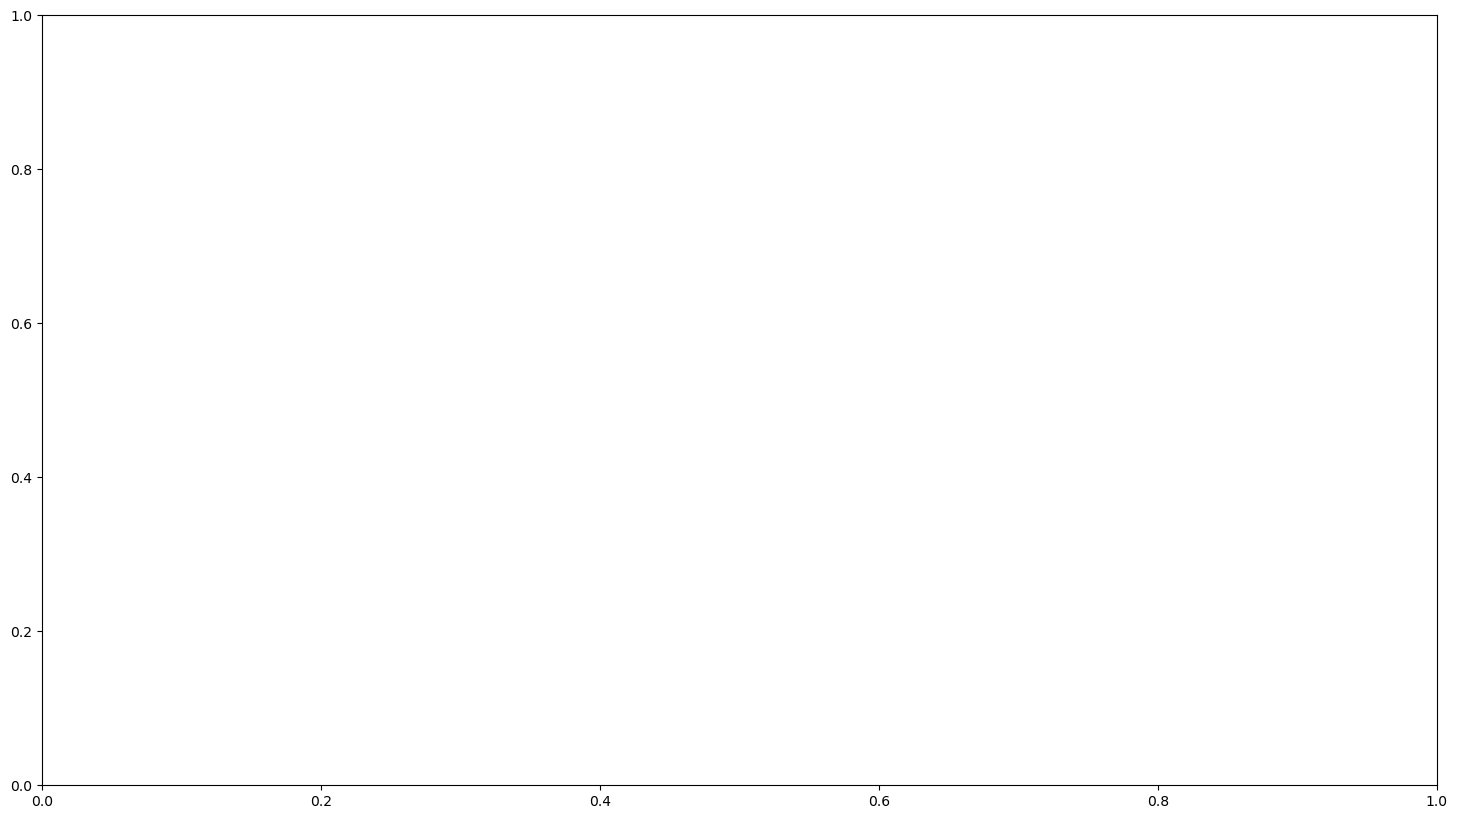

In [325]:
#Plot a Bar Chart of Purchasing Power

n_areas = len(pivot)
y = np.arange(n_areas)

fig, ax = plt.subplots(figsize=(18, 10))

offset = ( 0.35 + 0.1) /2

#Plot Residents
left = np.zeros(n_areas)
for i, col in enumerate(age_cols_res):
    ax.bar(y - offset, pivot['Purchasing Power (Residents)'], left=left, height= 0.35)

#Plot Visitors (no labels)
left = np.zeros(n_areas)
for i, col in enumerate(age_cols_vis):
    ax.bar(y + offset, pivot['Purchasing Power (Visitors)'], left=left, height= 0.35)

ax.set_yticks(y)
ax.set_yticklabels(pivot.index, fontsize= 16)
ax.tick_params(axis='x', labelsize= 16)
ax.set_xlabel('Purchasing Power (€ per capita)', fontsize= 20)
ax.set_title('Purchasing Power: Residents VS Visitors', fontsize= 22, weight= 'bold')
plt.tight_layout()
plt.show()

In [ ]:
#Purchasing Power Buckets Comaparison
pivot()


Note: Unsure how to investigate purchasing power buckets for visitors (have no residents comparison)

## Statistical Summary on Demographics

### A) Age

* Across the 13 areas, residents aged 19-29 represented the largest age group, accounting for 23.9% overall, and ranging from 13.5% to 40.3%. This was particularly pronounced in the 'Bradford City Centre' (40.3%), 'BD Walls - The Portal' (37%) and 'Draley Street Market' (37%).
* By contrast, the 45-59 and 60+ age groups constituted the smallest shares of residents across areas, each representing around 16%.
* In contrast to the resident profile, visitors across the 13 areas were predominantly aged 30-44, comprising 26.3% of visitors overall, ranging from 22.7% to 29.6%. This pattern was most evident in the 'BD Walls - The Portal' (29.5%), 'BD Walls Roots' (29.6%) areas.
* Visitors aged 45-59 formed the smallest visitor group, accounting for 23.49% of visitors.
* Visitors in 'Draley Street Market' area were 16.3% more likely to be aged over 60 than residents.

### B) Gender

* Resident gender distribution was broadly balanced across most areas. However, in the 'BD Walls - The Portal' and 'Draley Street Market' areas, the share of female residents were around 10% lower than male residents, indicating a notable gender imbalance.
* Visitors gender distribution were evenly distributed in all areas, showing no significant variation by location.

### C) Households and Population

* Across the 13 aresa, the average household size was 2.5.
* The Bradford BID area had the highest concentration of households, with a total of 6369 households.
* On average, areas had 7566 residents, with Bradford BID recodring the largest population of 17666 residents.


### D) Purchasing Power

* Across the areas, residents had an average of 19591 euros per capita purchasing power. 'Baildon' area had the highest purchasing power with 28024.93 euros per capita, and 'Coates Street, Bradford Foyer, Coates TER, Wootton Street' in contrast was the area with the lowest purchasing power of 11998.92 euros per capita.
* Across the areas, visitors had an average of 19055.99 euros per capita purchasing power. 'BD WALL - Wayfinders' area had the highest purchasing power with 25135.73 euros per capita, and 'BD Walls Roots' in contrast was the area with the lowest purchasing power of 15047.41 euros per capita.
* On average, residents' purchasing power was 15% higher than visitors'. The 'Draley Street Market' area for example had a 4288.01 euros per capita difference between its residents and visitors.
*

## II - Exploratory Data Analysis: Dwell

In [326]:
df_dwell

,area,common.dataType,Category,Value (All days of week),Value (Weekdays only),Value (Weekends only),region
0,"Coates Street, Bradford Foyer, Coates TER, Woo...",Dwell Time Distribution,0-30 min,36.8%,35.4%,41.0%,"Balancing Acts - 1 Coates Street, Bradford, BD..."
1,"Coates Street, Bradford Foyer, Coates TER, Woo...",Dwell Time Distribution,30-2hrs,24.1%,24.3%,23.5%,"Balancing Acts - 1 Coates Street, Bradford, BD..."
2,"Coates Street, Bradford Foyer, Coates TER, Woo...",Dwell Time Distribution,2-4 hrs,15.2%,17.5%,8.6%,"Balancing Acts - 1 Coates Street, Bradford, BD..."
3,"Coates Street, Bradford Foyer, Coates TER, Woo...",Dwell Time Distribution,4-6 hrs,8.0%,7.3%,10.0%,"Balancing Acts - 1 Coates Street, Bradford, BD..."
4,"Coates Street, Bradford Foyer, Coates TER, Woo...",Dwell Time Distribution,6-8 hrs,5.1%,5.4%,4.0%,"Balancing Acts - 1 Coates Street, Bradford, BD..."
...,...,...,...,...,...,...,...
191,Bradford - Penistone Hill,Dwell Time by Day of Week,Wednesday,56.0 minutes,56.0 minutes,0.0 minutes,WILD UPLANDS
192,Bradford - Penistone Hill,Dwell Time by Day of Week,Thursday,34.8 minutes,34.8 minutes,0.0 minutes,WILD UPLANDS
193,Bradford - Penistone Hill,Dwell Time by Day of Week,Friday,26.3 minutes,26.3 minutes,0.0 minutes,WILD UPLANDS
194,Bradford - Penistone Hill,Dwell Time by Day of Week,Saturday,38.7 minutes,0.0 minutes,38.7 minutes,WILD UPLANDS


In [329]:
#Take out the % and text for calculations
df_dwell[df_dwell['Value (All days of week)', 'Value (Weekdays only)', 'Value (Weekends only)']] = df_dwell[df_dwell['Value (All days of week)', 'Value (Weekdays only)', 'Value (Weekends only)']].str.replace('%', '', regex=True)
df_dwell[['Value (All days of week)', 'Value (Weekdays only)', 'Value (Weekends only)']] = df_dwell['Value (All days of week)', 'Value (Weekdays only)', 'Value (Weekends only)'].str.replace(' minutes', '', regex=True)
#Convert Value column to numerical instead of object
df_dwell[[['Value (All days of week)', 'Value (Weekdays only)', 'Value (Weekends only)']]] = pd.to_numeric(df_dwell[['Value (All days of week)', 'Value (Weekdays only)', 'Value (Weekends only)']], errors='coerce')
df_dwell.head()

KeyError: ('Value (All days of week)', 'Value (Weekdays only)', 'Value (Weekends only)')

In [ ]:
#Create pivot table for better readability
pivot = df_demo.pivot_table(index= 'area', 
                            columns= ['Category', 'Group'], 
                            values='Value',
                            aggfunc= 'mean')

pivot

Category                                           Age (Residents)        \
Group                                                         0-14 15-29   
area                                                                       
BD WALL - Wayfinders                                          16.5  15.2   
BD Walls - The Portal                                         19.3  37.0   
BD Walls : Serving the district                               19.0  16.6   
BD Walls Roots                                                29.0  23.3   
Baildon                                                       17.2  15.3   
Bradford                                                      25.2  23.8   
Bradford - City Centre                                        18.7  40.3   
Bradford - Penistone Hill                                     15.7  13.5   
Bradford BID                                                  24.2  31.1   
Coates Street, Bradford Foyer, Coates TER, Woot...            29.0  23.3   
Draley Street Market                                          19.3  37.0   
Reevy Road                                                    22.1  17.0   
Roundwood Avenue                                              21.0  17.0   

Category                                                              \
Group                                              30-44 45-59   60+   
area                                                                   
BD WALL - Wayfinders                                18.6  22.2  27.4   
BD Walls - The Portal                               29.8   8.8   5.1   
BD Walls : Serving the district                     17.9  21.3  25.1   
BD Walls Roots                                      23.2  13.3  11.2   
Baildon                                             21.4  21.0  25.0   
Bradford                                            23.3  14.5  13.1   
Bradford - City Centre                              24.3   9.8   6.9   
Bradford - Penistone Hill                           16.8  25.8  27.6   
Bradford BID                                        24.2  11.5   8.9   
Coates Street, Bradford Foyer, Coates TER, Woot...  23.2  13.3  11.2   
Draley Street Market                                29.8   8.8   5.1   
Reevy Road                                          19.3  20.2  21.4   
Roundwood Avenue                                    20.3  20.0  21.5   

Category                                           Age (Visitors)              \
Group                                                       15-29 30-44 45-59   
area                                                                            
BD WALL - Wayfinders                                         20.5  22.8  25.8   
BD Walls - The Portal                                        28.3  29.5  21.1   
BD Walls : Serving the district                              22.6  24.9  25.3   
BD Walls Roots                                               28.7  29.6  21.1   
Baildon                                                      20.5  23.0  25.8   
Bradford                                                     26.9  27.5  22.3   
Bradford - City Centre                                       28.2  27.4  21.9   
Bradford - Penistone Hill                                    19.8  22.7  26.6   
Bradford BID                                                 28.0  27.6  21.8   
Coates Street, Bradford Foyer, Coates TER, Woot...           26.5  28.7  22.4   
Draley Street Market                                         30.0  27.5  21.2   
Reevy Road                                                   23.4  25.4  24.9   
Roundwood Avenue                                             23.0  25.9  25.2   

Category                                                 Gender (Residents)  \
Group                                                60+                  F   
area                                                                          
BD WALL - Wayfinders                                30.9               49.9   
BD Walls - The Po

In [ ]:
pivot.describe()

Category Age (Residents)                                              \
Group               0-14      15-29      30-44      45-59        60+   
count          13.000000  13.000000  13.000000  13.000000  13.000000   
mean           21.246154  23.876923  22.469231  16.192308  16.115385   
std             4.417317   9.447500   4.077046   5.772992   8.722084   
min            15.700000  13.500000  16.800000   8.800000   5.100000   
25%            18.700000  16.600000  19.300000  11.500000   8.900000   
50%            19.300000  23.300000  23.200000  14.500000  13.100000   
75%            24.200000  31.100000  24.200000  21.000000  25.000000   
max            29.000000  40.300000  29.800000  25.800000  27.600000   

Category Age (Visitors)                                  Gender (Residents)  \
Group             15-29      30-44      45-59        60+                  F   
count         13.000000  13.000000  13.000000  13.000000          13.000000   
mean          25.107692  26.346154  23.492308  25.069231          48.915385   
std            3.586889   2.443909   2.105335   3.860782           2.516561   
min           19.800000  22.700000  21.100000  20.500000          44.800000   
25%           22.600000  24.900000  21.800000  22.500000          47.300000   
50%           26.500000  27.400000  22.400000  23.300000          49.000000   
75%           28.200000  27.600000  25.300000  27.200000          50.600000   
max           30.000000  29.600000  26.600000  30.900000          52.300000   

Category  ... Purchasing Power Buckets (Visitors)                            \
Group     ...                        Bucket 49000 Bucket 52500 Bucket 56000   
count     ...                                 2.0          2.0          3.0   
mean      ...                                 0.0          0.0          0.0   
std       ...                                 0.0          0.0          0.0   
min       ...                                 0.0          0.0          0.0   
25%       ...                                 0.0          0.0          0.0   
50%       ...                                 0.0          0.0          0.0   
75%       ...                                 0.0          0.0          0.0   
max       ...                                 0.0          0.0          0.0   

Category                                                                  \
Group    Bucket 63000 Bucket 66500 Bucket 7000 Bucket 70000 Bucket 80500   
count             4.0          2.0   13.000000          2.0          1.0   
mean              0.0          0.0    2.846154          0.0          0.0   
std               0.0          0.0    1.625123          0.0          NaN   
min               0.0          0.0    1.000000          0.0          0.0   
25%               0.0          0.0    2.000000          0.0          0.0   
50%               0.0          0.0    2.000000          0.0          0.0   
75%               0.0          0.0    4.000000          0.0          0.0   
max               0.0          0.0    6.000000          0.0          0.0   

Category                            
Group    Bucket 91000 Bucket 94500  
count             2.0          3.0  
mean              0.0          0.0  
std               0.0          0.0  
min               0.0          0.0  
25%               0.0          0.0  
50%               0.0          0.0  
75%               0.0          0.0  
max               0.0          0.0  

[8 rows x 41 columns]

In [ ]:
pivot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, BD WALL - Wayfinders to Roundwood Avenue
Data columns (total 41 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   (Age (Residents), 0-14)                               13 non-null     float64
 1   (Age (Residents), 15-29)                              13 non-null     float64
 2   (Age (Residents), 30-44)                              13 non-null     float64
 3   (Age (Residents), 45-59)                              13 non-null     float64
 4   (Age (Residents), 60+)                                13 non-null     float64
 5   (Age (Visitors), 15-29)                               13 non-null     float64
 6   (Age (Visitors), 30-44)                               13 non-null     float64
 7   (Age (Visitors), 45-59)                               13 non-null     float64
 8   (Age (Visitors), 60+)             

## III - Exploratory Data Analysis: Footfall

## IV - Exploratory Data Analysis: Sales